In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

### Detección de ouliers con ***Isolation Forest***

Los outliers van a tener en promedio una profundidad mas pequeña

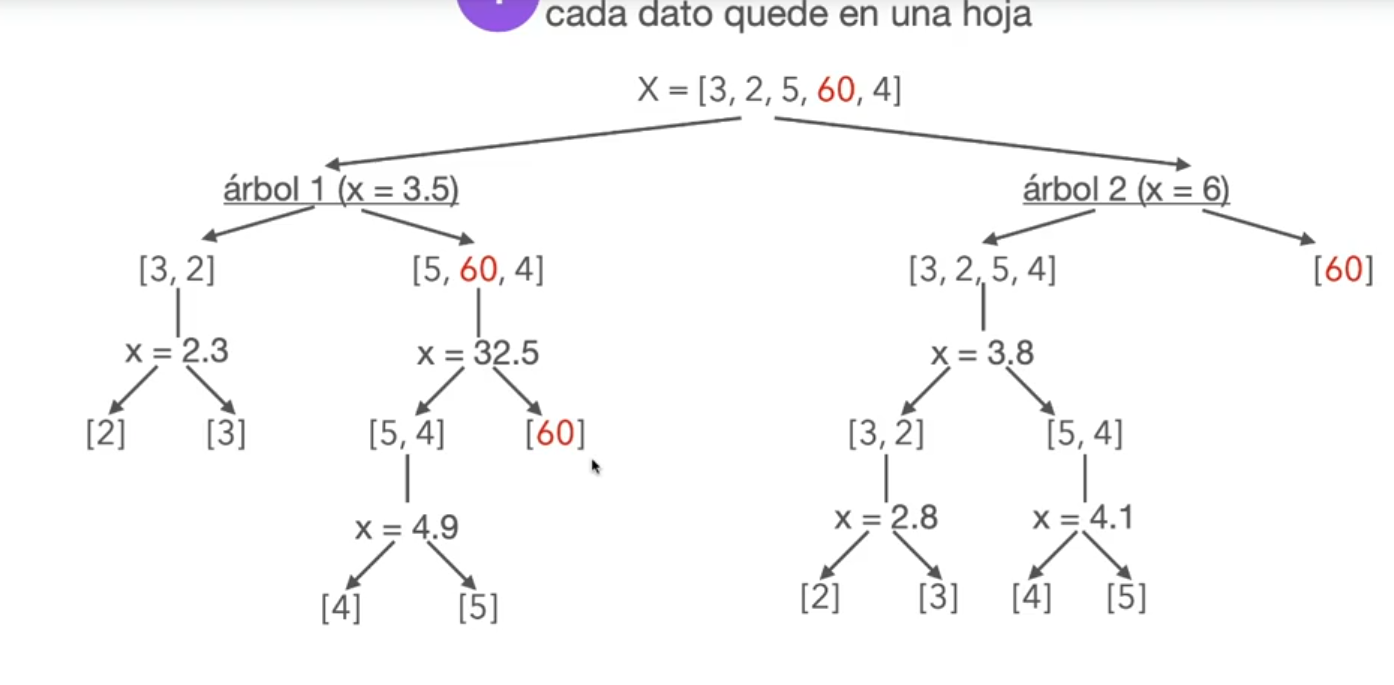

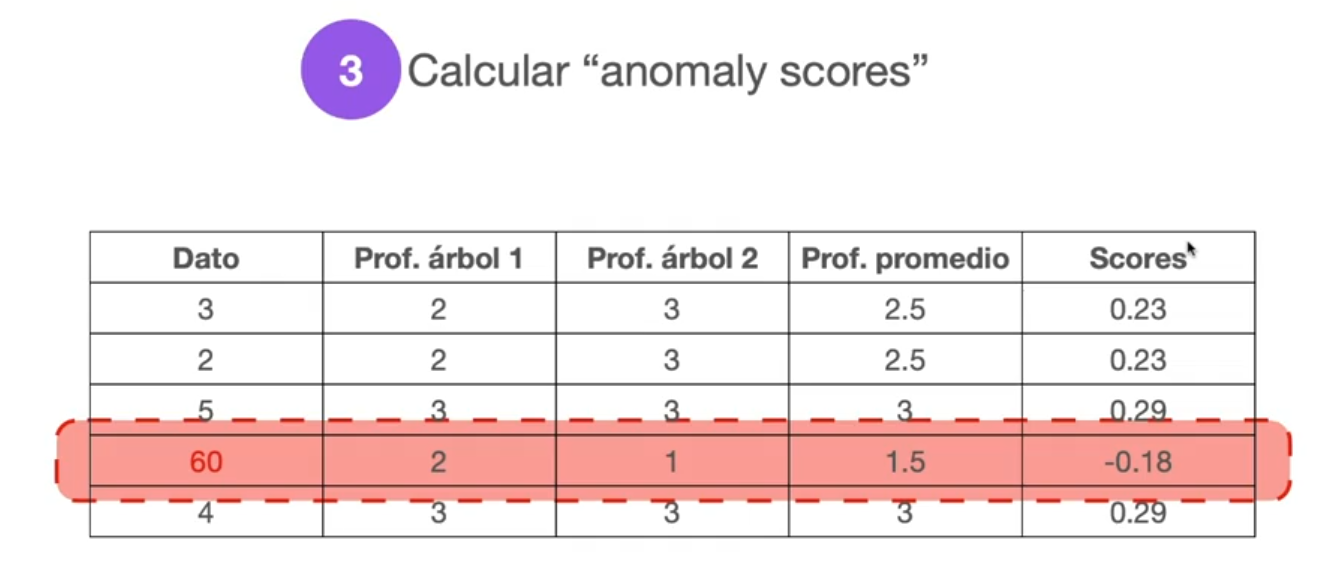

[-1 (Outlier), 1 (Dato normal)]:


 Se implementa un umbral: **"Proporción de valores extremos esperados con respecto a la totalidad de los datos"**

 * contamination : El umbral que usaremos al momento de la clasificación
 * n_estimators  : Número de arboles iniciales
 * random_state  : semilla

### Implementación con Scikit Learn

In [4]:
X = np.array([3, 2, 5, 60, 4]).reshape(-1, 1)
X

array([[ 3],
       [ 2],
       [ 5],
       [60],
       [ 4]])

In [25]:
iso_forest = IsolationForest(contamination = 1/5,
                            n_estimators = 20,
                            random_state = 123)
iso_forest

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",20
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.2
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",123
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [26]:
iso_forest.fit(X)
scores = iso_forest.decision_function(X)

for i, x in enumerate(X):
    print(f'Característica: {x} \tscore: {np.round(scores[i], 4)}')

Característica: [3] 	score: 0.1906
Característica: [2] 	score: 0.1315
Característica: [5] 	score: 0.0549
Característica: [60] 	score: -0.2196
Característica: [4] 	score: 0.1649


In [27]:
preds = iso_forest.predict(X)

for i, x in enumerate(X):
    print(f'Característica: {x} \tpred: {preds[i]}')


Característica: [3] 	pred: 1
Característica: [2] 	pred: 1
Característica: [5] 	pred: 1
Característica: [60] 	pred: -1
Característica: [4] 	pred: 1


### Usando en series de tiempo

In [32]:
def graficar_outliers(serie, fechas, outliers = None):
    ax = serie.plot(alpha = 0.7)

    serie.loc[fechas].plot(ax = ax, style = 'bo')

    if outliers is not None:
        outliers.plot(ax = ax, style = 'rx')
        plt.legend(['Serie de tiempo', 'Outliers conocidos', 'Outliers desconocidos'])
    else:
        plt.legend(['Serie de tiempo', 'Outliers conocidos'])
    
    plt.xlabel('Fecha')
    plt.ylabel('# pasajeros')

In [36]:
taxis = pd.read_csv('datos/taxis_ny.csv',
                    parse_dates=['tiempo'],
                    index_col='tiempo')
fechas = [
    '2014-11-01',
    '2014-11-27',
    '2014-12-25',
    '2015-01-01',
    '2015-01-27']

tx_diaria = taxis.resample('D').mean()

In [39]:
def outliers_isolation_forest(serie, umbral=0.1):
    x = serie.to_numpy().reshape(-1,1)

    bosque = IsolationForest(contamination = umbral,
                                random_state = 0)
    bosque.fit(x)
    preds = bosque.predict(x)
    outliers = serie[preds == -1]

    return outliers

215


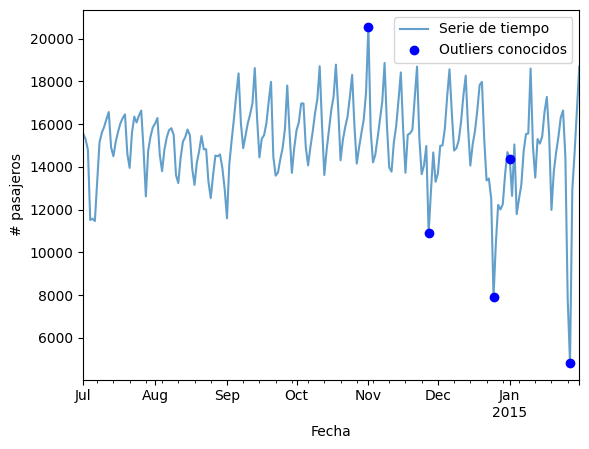

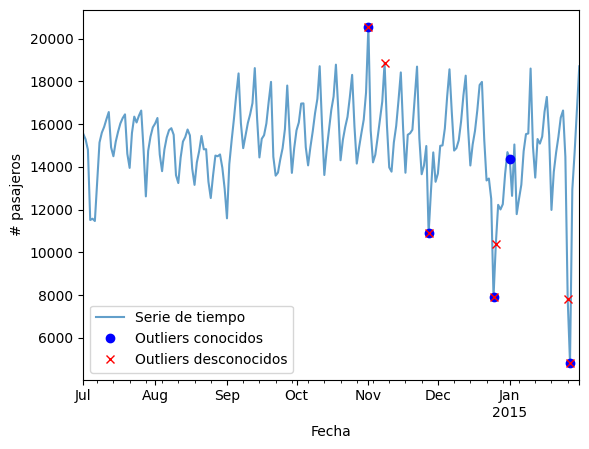

In [47]:
graficar_outliers(tx_diaria, fechas)
print(len(tx_diaria))
# el umbral se puede esperar como 5/215
umbral = 7/215
outliers_if = outliers_isolation_forest(tx_diaria, umbral) 
graficar_outliers(tx_diaria, fechas, outliers_if)